# Part 3 NLP: Sentiment Analysis
**Dataset:** IMDb Movie Reviews (binary: positive=1, negative=0)


## 0. Install / Import Dependencies

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q tensorflow nltk contractions gensim
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.6 MB/s eta 0:00:00


True

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

# NLP tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Sklearn metrics and splitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score
)

# Gensim for loading pre-trained word vectors
import gensim.downloader as api

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('All imports ✓')


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports ✓


---
## 1. Data Loading & Cleaning

In [6]:
TRAIN_PATH = '/content/drive/MyDrive/AI/Movie Review Dataset/train_movie_review.csv'
TEST_PATH  = '/content/drive/MyDrive/AI/Movie Review Dataset/test_movie_review.csv'
VAL_PATH   = '/content/drive/MyDrive/AI/Movie Review Dataset/val_movie_review.csv'

TEXT_COL  = 'review'
LABEL_COL = 'sentiment'

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)
df_val   = pd.read_csv(VAL_PATH)

print('Train:', df_train.shape, '| Test:', df_test.shape, '| Val:', df_val.shape)
df_train.head(3)


Train: (35000, 3) | Test: (10000, 3) | Val: (5000, 3)


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0


In [7]:
# Remove rows with missing text or label values
for tag, df in [('Train', df_train), ('Test', df_test), ('Val', df_val)]:
    before = len(df)
    df.dropna(subset=[TEXT_COL, LABEL_COL], inplace=True)
    print(f'{tag}: dropped {before - len(df)} nulls → {len(df)} rows')

# Keep only binary labels (0 = negative, 1 = positive)
for df in [df_train, df_test, df_val]:
    df.drop(df[~df[LABEL_COL].isin([0, 1])].index, inplace=True)
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    df.reset_index(drop=True, inplace=True)

print('\nLabel distribution (train):')
print(df_train[LABEL_COL].value_counts())


Train: dropped 0 nulls → 35000 rows
Test: dropped 0 nulls → 10000 rows
Val: dropped 0 nulls → 5000 rows

Label distribution (train):
sentiment
0    17584
1    17416
Name: count, dtype: int64


In [8]:
# Text cleaning pipeline
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = contractions.fix(text)                        # expand contractions e.g. don't → do not
    text = text.lower()                                  # lowercase everything
    text = re.sub(r'<[^>]+>', ' ', text)                 # strip HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'@\w+', ' ', text)                    # remove @mentions
    text = re.sub(r'#\w+', ' ', text)                    # remove hashtags
    text = re.sub(r'\d+', ' ', text)                     # remove digits
    text = re.sub(r'[^\w\s]', ' ', text)                 # remove remaining punctuation
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in STOP_WORDS and len(t) > 1
    ]
    return ' '.join(tokens)

print('Cleaning train…')
df_train['clean_text'] = df_train[TEXT_COL].astype(str).apply(clean_text)
print('Cleaning test…')
df_test['clean_text']  = df_test[TEXT_COL].astype(str).apply(clean_text)
print('Cleaning val…')
df_val['clean_text']   = df_val[TEXT_COL].astype(str).apply(clean_text)

print('\nSample cleaned review:')
print(df_train['clean_text'].iloc[0])


Cleaning train…
Cleaning test…
Cleaning val…

Sample cleaned review:
avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another characterisation dance number heavily choreographed according extra dvd thrown away half body ever screen dance chorus north european appear small greek island set set number would disgraced cliff richard musical sixty meryl see acting streep cannot even make usual mugging effective top musical grand piece winner take meryl met note director shot stillness camera gradually showing distance growing streep brosnan singing awful karaoke amateur night camera cannot stop moving like bad mtv one never settle enjoy music enthusiasm character even worse botched piece excre become highest grossing film uk best selling dvd boot blair campbell new labour really reduced uk zombie critical facu

---
## 2. Train-Test Split

We have 3 pre-split CSVs. We merge train + val first, then apply an 80/20
`train_test_split` to produce the canonical `X_train / X_test / y_train / y_test`
variables. The original `df_test` is kept separately as a held-out final
evaluation set.

In [9]:
# Merge train and validation sets, then apply an 80/20 stratified split
df_all = pd.concat([df_train, df_val], ignore_index=True)

X_all = df_all['clean_text'].values
y_all = df_all[LABEL_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all          # keeps class ratio equal in both splits
)

# The original CSV test set is held out for final evaluation only
X_final = df_test['clean_text'].values
y_final = df_test[LABEL_COL].values

print(f'X_train: {len(X_train)} | X_test: {len(X_test)}')
print(f'Train pos: {y_train.sum()} | Train neg: {(y_train==0).sum()}')
print(f'Held-out final test set: {len(X_final)}')


X_train: 32000 | X_test: 8000
Train pos: 15969 | Train neg: 16031
Held-out final test set: 10000


---
## 3. Tokenisation + Padding

In [10]:
MAX_WORDS = 20_000
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)          # vocabulary built from training data only

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)
X_final_seq = tokenizer.texts_to_sequences(X_final)

lengths = [len(s) for s in X_train_seq]
p95     = int(np.percentile(lengths, 95))
MAX_LEN = min(p95, 300)   # cap at 300 to keep memory and training time manageable
print(f'95th-pct = {p95}  →  MAX_LEN = {MAX_LEN}')

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')
X_final_pad = pad_sequences(X_final_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print('X_train_pad:', X_train_pad.shape)
print('X_test_pad :', X_test_pad.shape)

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print('Vocab size :', VOCAB_SIZE)


95th-pct = 309  →  MAX_LEN = 300
X_train_pad: (32000, 300)
X_test_pad : (8000, 300)
Vocab size : 20000


---
## 4. Shared Helpers

In [11]:
def plot_history(history, model_name: str):
    """Training vs validation accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_pad, y_true, model_name: str):
    """Accuracy, classification report, and confusion matrix."""
    y_prob = model.predict(X_pad, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    acc    = accuracy_score(y_true, y_pred)

    print(f'\n{"="*55}')
    print(f'  {model_name}  —  Accuracy: {acc:.4f}')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred,
                                 target_names=['Negative', 'Positive']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg (pred)', 'Pos (pred)'],
                yticklabels=['Neg (true)', 'Pos (true)'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return y_pred, y_prob


def error_analysis(X_raw, y_true, y_pred, n: int = 3):
    """Print n wrong predictions: predicted vs actual."""
    label_map = {0: 'Negative', 1: 'Positive'}
    wrong_idx = np.where(y_true != y_pred)[0]
    print(f'\n--- Error Analysis ({len(wrong_idx)} total misclassified) ---')
    for i, idx in enumerate(wrong_idx[:n]):
        print(f'\n[{i+1}] Review snippet  : {X_raw[idx][:120]}…')
        print(f'     Actual label   : {label_map[y_true[idx]]}')
        print(f'     Predicted label: {label_map[y_pred[idx]]}')


print('Helpers defined ✓')

Helpers defined ✓


---
## 5. Model 1: Simple RNN (Scratch Embeddings)

In [12]:
# Shared hyperparameters for all three models
EMBEDDING_DIM = 128   # embedding size for models 1 and 2 (trained from scratch)
RNN_UNITS     = 64
LSTM_UNITS    = 128
BATCH_SIZE    = 64
EPOCHS        = 20    # actual number of epochs is controlled by early stopping

# Callbacks used by all models during training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Bidirectional

def make_callbacks(patience=4):
    """Returns EarlyStopping and ReduceLROnPlateau callbacks."""
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,           # wait this many epochs before stopping
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1
        ),
    ]

# Model 1: Bidirectional SimpleRNN with trainable embedding
tf.random.set_seed(42)

model_rnn = Sequential([
    Input(shape=(MAX_LEN,), name='input_rnn'),
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              name='embedding_rnn'),
    Bidirectional(SimpleRNN(units=RNN_UNITS,
                            dropout=0.3,
                            name='simple_rnn')),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid', name='output_rnn')
], name='SimpleRNN_Model')

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=5e-4),
    metrics=['accuracy']
)
model_rnn.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_rnn (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,865 (9.88 MB)

 Trainable params: 2,588,865 (9.88 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(patience=4),
    verbose=1
)


Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.6563 - loss: 0.5846 - val_accuracy: 0.8453 - val_loss: 0.3705 - learning_rate: 5.0000e-04
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.8710 - loss: 0.3254 - val_accuracy: 0.8728 - val_loss: 0.3428 - learning_rate: 5.0000e-04
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.9056 - loss: 0.2515 - val_accuracy: 0.8800 - val_loss: 0.3392 - learning_rate: 5.0000e-04
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.9438 - loss: 0.1596 - val_accuracy: 0.8681 - val_loss: 0.4436 - learning_rate: 5.0000e-04
Epoch 5/20
449/450 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9636 - loss: 0.1126
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
450/450 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.9644 - loss: 0.1102 - val_accuracy: 0.8678 - val_loss: 0.5341 - learning_rate: 5.0000e-04
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - ac

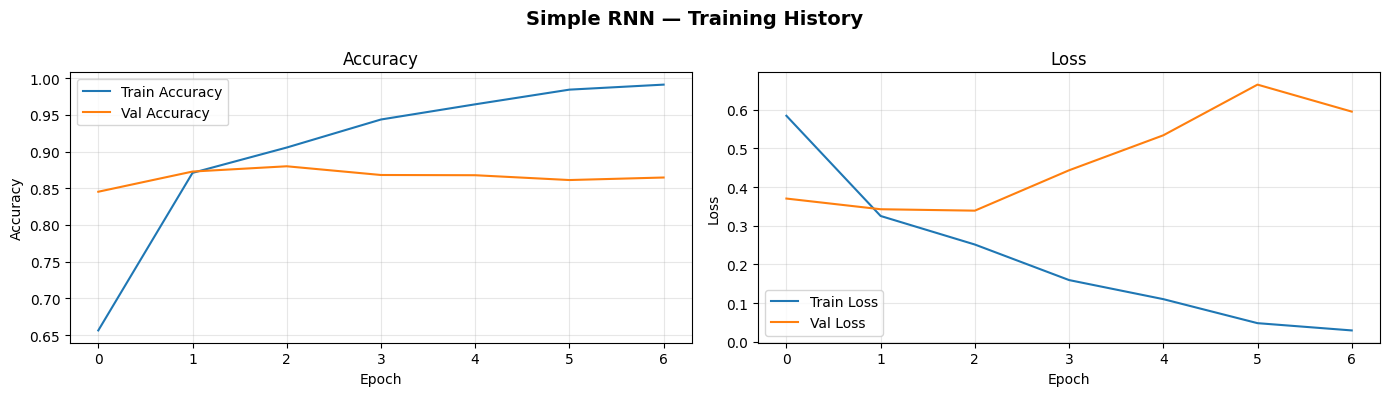


  Simple RNN  —  Accuracy: 0.8724
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      4008
    Positive       0.86      0.88      0.87      3992

    accuracy                           0.87      8000
   macro avg       0.87      0.87      0.87      8000
weighted avg       0.87      0.87      0.87      8000



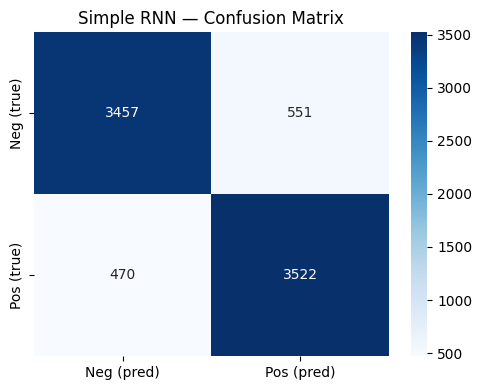


--- Error Analysis (1021 total misclassified) ---

[1] Review snippet  : quite fan novelist screenwriter michael chabon novel wonder boy became fantastic movie curtis hanson masterful novel ama…
     Actual label   : Negative
     Predicted label: Positive

[2] Review snippet  : watching film experienced new sensation watched film lead actor put performance almost rivaled legend chevy chase fletch…
     Actual label   : Positive
     Predicted label: Negative

[3] Review snippet  : one favourite film everything rocking soundtrack courtesy eddie clark ex motorhead load action load laugh totally ridicu…
     Actual label   : Positive
     Predicted label: Negative


In [14]:
plot_history(history_rnn, 'Simple RNN')
y_pred_rnn, _ = evaluate_model(model_rnn, X_test_pad, y_test, 'Simple RNN')
error_analysis(X_test, y_test, y_pred_rnn)

---
## 6. Model 2: LSTM (Scratch Embeddings)

In [15]:
# Model 2: Bidirectional LSTM with trainable embedding
# Two stacked LSTM layers are used so the first layer passes its full sequence
# output to the second, allowing deeper sequential features to be learned
tf.random.set_seed(42)

model_lstm = Sequential([
    Input(shape=(MAX_LEN,), name='input_lstm'),
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              name='embedding_lstm'),
    Bidirectional(LSTM(units=LSTM_UNITS,
                       dropout=0.3,
                       return_sequences=True,   # pass full sequence to next layer
                       name='lstm_layer_1')),
    Bidirectional(LSTM(units=64,
                       dropout=0.3,
                       name='lstm_layer_2')),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid', name='output_lstm')
], name='LSTM_Scratch_Model')

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=5e-4),
    metrics=['accuracy']
)
model_lstm.summary()


Model: "LSTM_Scratch_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_lstm (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,995,841 (11.43 MB)

 Trainable params: 2,995,841 (11.43 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(patience=4),
    verbose=1
)


Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step - accuracy: 0.8050 - loss: 0.4180 - val_accuracy: 0.8894 - val_loss: 0.2946 - learning_rate: 5.0000e-04
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.9171 - loss: 0.2256 - val_accuracy: 0.8806 - val_loss: 0.3443 - learning_rate: 5.0000e-04
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9415 - loss: 0.1724
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
450/450 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.9465 - loss: 0.1604 - val_accuracy: 0.8772 - val_loss: 0.4013 - learning_rate: 5.0000e-04
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.9696 - loss: 0.0989 - val_accuracy: 0.8869 - val_loss: 0.3896 - learning_rate: 2.5000e-04
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9805 - loss: 0.0681
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
450/450 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy

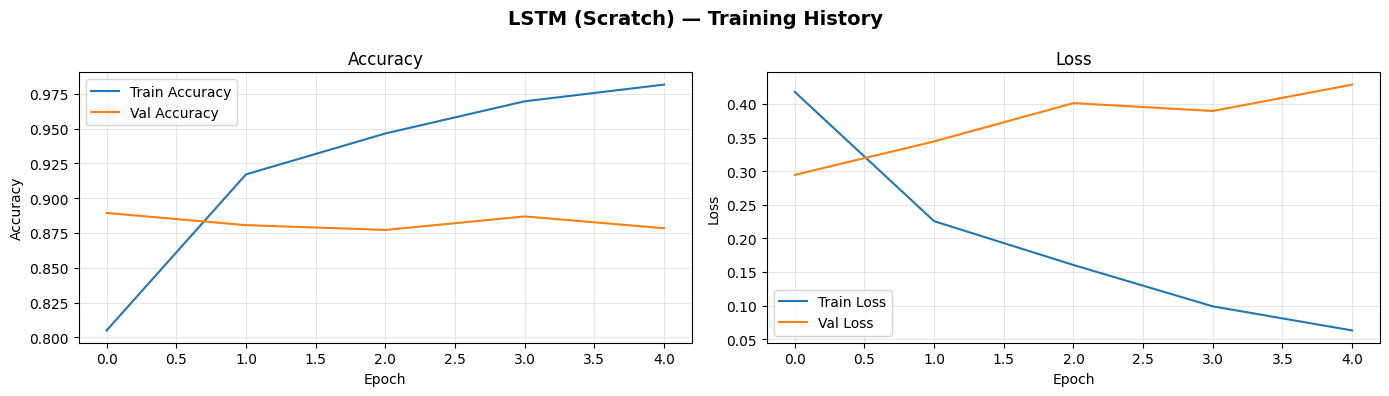


  LSTM (Scratch)  —  Accuracy: 0.8814
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      4008
    Positive       0.88      0.88      0.88      3992

    accuracy                           0.88      8000
   macro avg       0.88      0.88      0.88      8000
weighted avg       0.88      0.88      0.88      8000



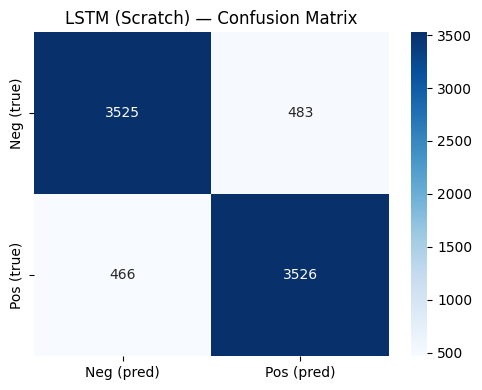


--- Error Analysis (949 total misclassified) ---

[1] Review snippet  : quite fan novelist screenwriter michael chabon novel wonder boy became fantastic movie curtis hanson masterful novel ama…
     Actual label   : Negative
     Predicted label: Positive

[2] Review snippet  : watching film experienced new sensation watched film lead actor put performance almost rivaled legend chevy chase fletch…
     Actual label   : Positive
     Predicted label: Negative

[3] Review snippet  : let rating writing fool one excellent film cannot fathom got rating considering solid level direction acting cinematogra…
     Actual label   : Positive
     Predicted label: Negative


In [17]:
plot_history(history_lstm, 'LSTM (Scratch)')
y_pred_lstm, _ = evaluate_model(model_lstm, X_test_pad, y_test, 'LSTM (Scratch)')
error_analysis(X_test, y_test, y_pred_lstm)

---
## 7. Model 3: LSTM + Pre-trained GloVe Embeddings
### 7a. Load Pre-trained Embeddings

In [18]:
# Download pre-trained GloVe vectors (100-dimensional, ~128 MB)
# These vectors were trained on 6 billion tokens from Wikipedia and Gigaword
print('Loading GloVe (glove-wiki-gigaword-100) — ~128 MB, one-time download…')
embedding_model = api.load('glove-wiki-gigaword-100')
GLOVE_DIM = 100
print(f'Loaded ✓  vocab: {len(embedding_model.key_to_index):,}')


Loading GloVe (glove-wiki-gigaword-100) — ~128 MB, one-time download…
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded ✓  vocab: 400,000


### 7b. Build Embedding Matrix

In [19]:
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found = not_found = 0

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model.key_to_index:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100
print(f'Matrix shape : {VOCAB_SIZE} × {GLOVE_DIM}')
print(f'Found: {found:,} | Not found: {not_found:,} | Coverage: {coverage:.1f}%')

Matrix shape : 20000 × 100
Found: 19,837 | Not found: 162 | Coverage: 99.2%


### 7c. Frozen Embedding Layer + LSTM

In [20]:
# Model 3: Bidirectional LSTM with GloVe pre-trained embedding
# The embedding layer is initialised with GloVe weights and kept trainable
# so the vectors can be fine-tuned on the movie review domain
tf.random.set_seed(42)

model_lstm_glove = Sequential([
    Input(shape=(MAX_LEN,), name='input_glove'),
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=GLOVE_DIM,
              weights=[embedding_matrix],
              trainable=True,          # allow fine-tuning on this dataset
              name='embedding_glove'),
    Bidirectional(LSTM(units=LSTM_UNITS,
                       dropout=0.3,
                       return_sequences=True,
                       name='lstm_glove_1')),
    Bidirectional(LSTM(units=64,
                       dropout=0.3,
                       name='lstm_glove_2')),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid', name='output_glove')
], name='LSTM_GloVe_Model')

model_lstm_glove.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=2e-4),   # lower rate for fine-tuning pre-trained weights
    metrics=['accuracy']
)
model_lstm_glove.summary()


Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ (None, 300, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 300, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_glove (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,407,169 (9.18 MB)

 Trainable params: 2,407,169 (9.18 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_glove = model_lstm_glove.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(patience=4),
    verbose=1
)


Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.6820 - loss: 0.5931 - val_accuracy: 0.8037 - val_loss: 0.4472 - learning_rate: 2.0000e-04
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.7864 - loss: 0.4701 - val_accuracy: 0.8087 - val_loss: 0.4796 - learning_rate: 2.0000e-04
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.8206 - loss: 0.4085 - val_accuracy: 0.8462 - val_loss: 0.3618 - learning_rate: 2.0000e-04
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.8413 - loss: 0.3749 - val_accuracy: 0.8281 - val_loss: 0.3706 - learning_rate: 2.0000e-04
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.8599 - loss: 0.3413 - val_accuracy: 0.8641 - val_loss: 0.3414 - learning_rate: 2.0000e-04
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.8734 - loss: 0.3128 - val_accuracy: 0.8691 - val_loss: 0.3210 - learning_rate: 2.0000e-04
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/ste

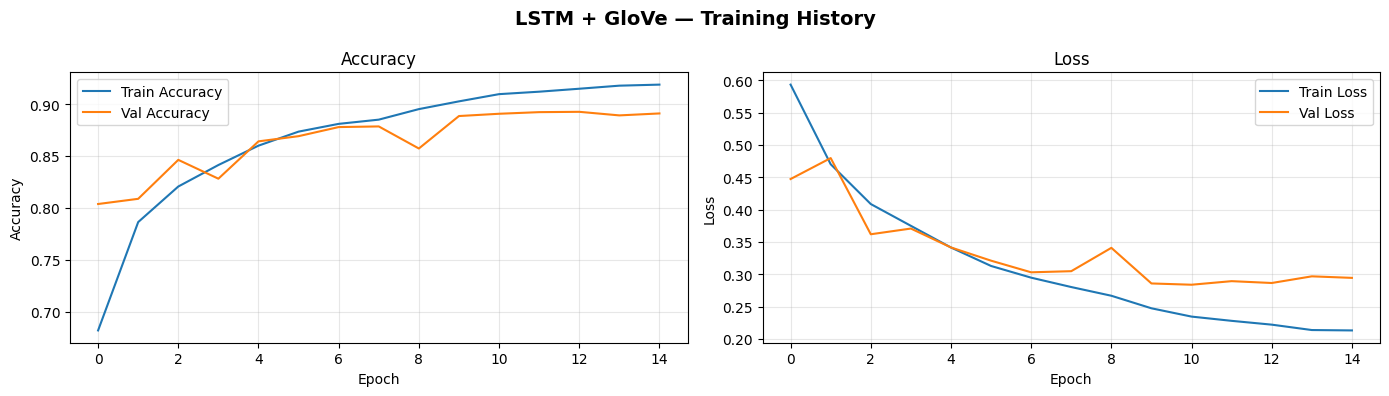


  LSTM + GloVe  —  Accuracy: 0.8864
              precision    recall  f1-score   support

    Negative       0.90      0.86      0.88      4008
    Positive       0.87      0.91      0.89      3992

    accuracy                           0.89      8000
   macro avg       0.89      0.89      0.89      8000
weighted avg       0.89      0.89      0.89      8000



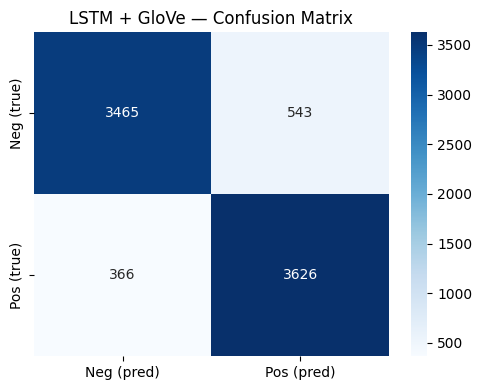


--- Error Analysis (909 total misclassified) ---

[1] Review snippet  : let rating writing fool one excellent film cannot fathom got rating considering solid level direction acting cinematogra…
     Actual label   : Positive
     Predicted label: Negative

[2] Review snippet  : fine concept piece acting brando fine piece work dean martin bad montgomery clift quite good well unfortunately disjoint…
     Actual label   : Negative
     Predicted label: Positive

[3] Review snippet  : one favourite film everything rocking soundtrack courtesy eddie clark ex motorhead load action load laugh totally ridicu…
     Actual label   : Positive
     Predicted label: Negative


In [22]:
plot_history(history_glove, 'LSTM + GloVe')
y_pred_glove, _ = evaluate_model(model_lstm_glove, X_test_pad, y_test, 'LSTM + GloVe')
error_analysis(X_test, y_test, y_pred_glove)

---
## 8. Model Comparison Summary

              Accuracy  Precision  Recall  F1-Score
Model                                              
Simple RNN      0.8724     0.8647  0.8823    0.8734
LSTM Scratch    0.8814     0.8795  0.8833    0.8814
LSTM + GloVe    0.8864     0.8698  0.9083    0.8886


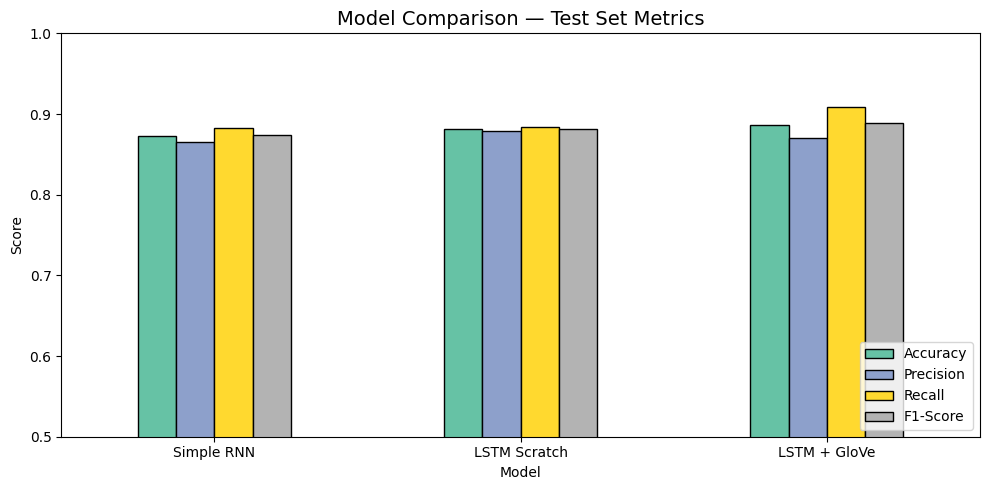

In [23]:
results = []
for name, y_pred in [
    ('Simple RNN',   y_pred_rnn),
    ('LSTM Scratch', y_pred_lstm),
    ('LSTM + GloVe', y_pred_glove),
]:
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
    })

summary_df = pd.DataFrame(results).set_index('Model').round(4)
print(summary_df.to_string())

summary_df.plot(kind='bar', figsize=(10, 5), ylim=(0.5, 1.0),
                colormap='Set2', edgecolor='black')
plt.title('Model Comparison — Test Set Metrics', fontsize=14)
plt.xlabel('Model'); plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()